<a href="https://colab.research.google.com/github/IvoZal/pytorch-deep-learning-my-fork/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Tue Apr 15 17:44:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

2.6.0+cu124


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

In [3]:
print(['ADAS', 'visual inspection', 'security'])

['ADAS', 'visual inspection', 'security']


## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [4]:
'the ability of model to fit on noise in data'

'the ability of model to fit on noise in data'

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [5]:
['cross validation', 'early stopping', 'dropout', 'ensemble methods']

['cross validation', 'early stopping', 'dropout', 'ensemble methods']

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [6]:
import torchvision
from torchvision import transforms

train_dataset = torchvision.datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor())

test_dataset = torchvision.datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:10<00:00, 909kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 65.5kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 245kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.99MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

60000
10000


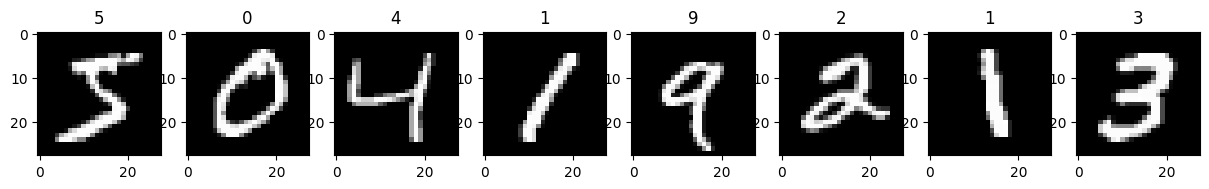

In [7]:
import matplotlib.pyplot as plt

print(len(train_dataset))
print(len(test_dataset))

n_samples = 8

fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))

for n in range(n_samples):
  img, label = train_dataset[n]

  axes[n].set_title(label)
  axes[n].imshow(img.squeeze(), cmap='grey')


## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [9]:
from torch import nn

class MnistModelV0(nn.Module):
  """
  Parameters:
  - input_shape: Size of the input image, expect NCHW format.
  - hidden_units: Number of filters in the convolutional layers.
  - output_shape: Number of output units in the final linear layer (number of output classes).
  """
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    input_channels = input_shape[1]
    n_pooling = 2
    nn_linear_inputs = (input_shape[2] // (2 ** n_pooling)) * (input_shape[3] // (2 ** n_pooling))

    self.block_1 = nn.Sequential(
        nn.Conv2d(input_channels, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * nn_linear_inputs,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.block_1(x)
    # print(f'Block 1 output: {x.shape}')
    x = self.block_2(x)
    # print(f'Block 2 output: {x.shape}')
    x = self.classifier(x)
    # print(f'Output: {x.shape}')
    return(x)

Inference with model

In [10]:
img, label = next(iter(train_loader))
img_channels = img.shape[1]

classes = train_dataset.classes

model_0 = MnistModelV0(input_shape=img.shape,
                       hidden_units=10,
                       output_shape=len(classes))

print(f'Image shape: {img.shape}')
print(f'Number of image channels: {img_channels}')
print(f'Number of classes in dataset: {len(classes)}')

print('\nModel:')

print(model_0)

model_0(img)


Image shape: torch.Size([32, 1, 28, 28])
Number of image channels: 1
Number of classes in dataset: 10

Model:
MnistModelV0(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


tensor([[ 7.7580e-02,  2.6539e-02,  4.7321e-03,  7.8408e-03, -2.1823e-02,
          6.4388e-02, -5.7734e-02, -1.1371e-02, -1.6048e-02, -2.5720e-04],
        [ 6.5867e-02,  2.6175e-02, -5.5367e-03,  7.8832e-03, -1.7655e-02,
          6.0770e-02, -5.2051e-02, -8.1696e-03, -2.2519e-02,  8.0042e-03],
        [ 6.4826e-02,  2.5243e-02, -5.2207e-03,  9.6073e-03, -1.6983e-02,
          6.6317e-02, -5.0874e-02, -5.6046e-03, -2.5700e-02,  4.9805e-03],
        [ 7.1739e-02,  2.4165e-02, -3.5812e-03,  8.5168e-03, -2.5535e-02,
          6.0483e-02, -6.5022e-02, -8.9449e-04, -2.2100e-02,  2.2663e-03],
        [ 6.9478e-02,  2.3006e-02, -1.6169e-03,  1.2972e-02, -2.1582e-02,
          6.1949e-02, -6.0715e-02, -6.9414e-04, -2.2655e-02, -4.1483e-04],
        [ 6.7831e-02,  2.3128e-02,  3.4515e-03,  7.3133e-03, -2.0125e-02,
          5.7898e-02, -5.2957e-02, -7.9834e-03, -2.2521e-02,  6.9802e-03],
        [ 6.7635e-02,  1.9502e-02,  8.6169e-03, -4.9046e-03, -3.0101e-02,
          6.7475e-02, -5.4177e-0

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [11]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

# Optimizer
optim = torch.optim.SGD(model_0.parameters(), lr=0.03)
# Loss function
loss_fn = nn.CrossEntropyLoss()
# Accuracy function
# Import accuracy metric
from helper_functions import accuracy_fn

In [12]:
# Train function
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        # Go from logits -> pred labels
        train_acc += accuracy_fn(y_pred.argmax(dim=1), y)

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

# Test function
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(test_pred.argmax(dim=1), y)

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [13]:
epochs = 5

for epoch in range(epochs):
  train_step(
      model = model_0,
      data_loader=train_loader,
      loss_fn=loss_fn,
      optimizer=optim,
      accuracy_fn=accuracy_fn,
      device=device
  )
  test_step(
      model = model_0,
      data_loader=train_loader,
      loss_fn=loss_fn,
      accuracy_fn=accuracy_fn,
      device=device
  )

Train loss: 0.43951 | Train accuracy: 85.06%
Test loss: 0.10294 | Test accuracy: 96.73%

Train loss: 0.08833 | Train accuracy: 97.25%
Test loss: 0.07036 | Test accuracy: 97.75%

Train loss: 0.06852 | Train accuracy: 97.86%
Test loss: 0.05814 | Test accuracy: 98.16%

Train loss: 0.05781 | Train accuracy: 98.19%
Test loss: 0.05176 | Test accuracy: 98.42%

Train loss: 0.05172 | Train accuracy: 98.43%
Test loss: 0.04237 | Test accuracy: 98.70%



## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

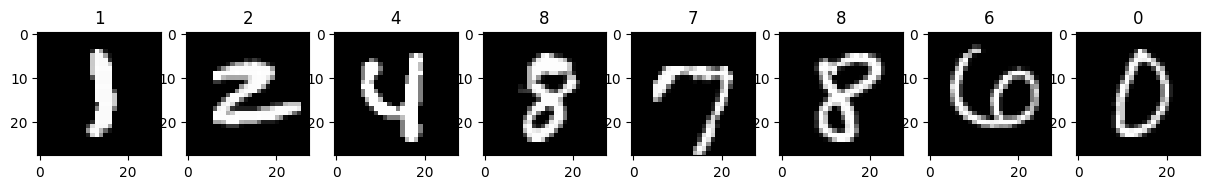

In [16]:
n_samples = 8

fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))

for n in range(n_samples):
  images, labels = next(iter(train_loader))

  img = images[0]
  label = labels[0].item()

  axes[n].set_title(label)
  axes[n].imshow(img.squeeze(), cmap='grey')

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?